<a href="https://colab.research.google.com/github/westoryyyy/TaskFlow-1/blob/main/WATER%20POTABILITY_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Preprocessing & Exploratory Data Analysis (EDA)**

--- Distribusi Target (Potability) ---
Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64


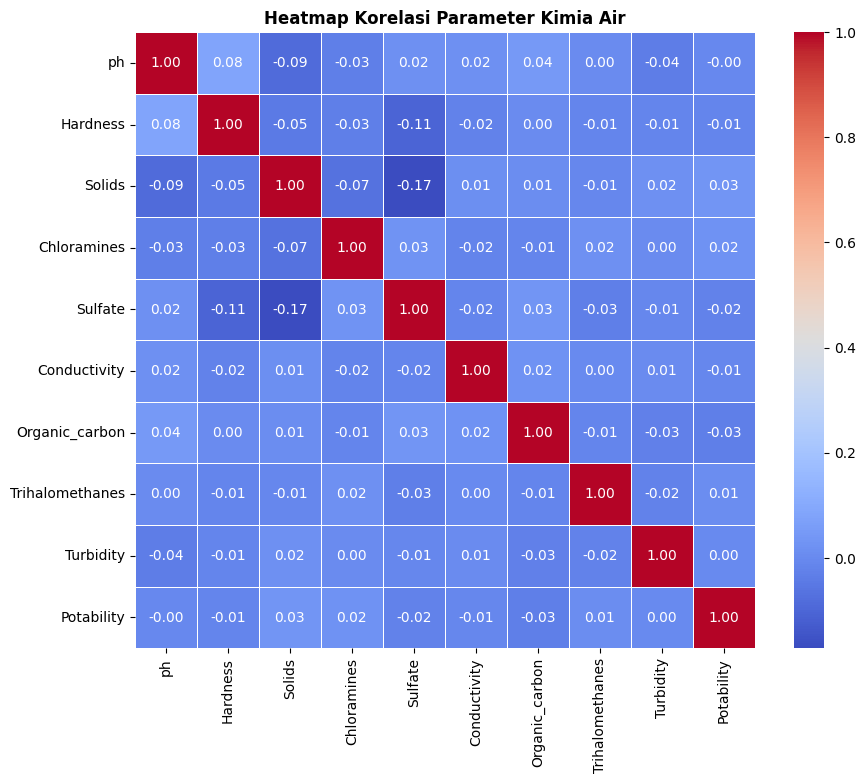


[INFO] Tahap EDA dan Preprocessing Selesai!


/tmp/ipykernel_10806/1022918200.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ph'].fillna(df['ph'].mean(), inplace=True)
/tmp/ipykernel_10806/1022918200.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load Dataset
df = pd.read_csv('water_potability.csv')

# 2. EDA: Cek persentase target data (Proporsi Air Layak vs Tidak)
print("--- Distribusi Target (Potability) ---")
print(df['Potability'].value_counts(normalize=True))

# 3. EDA: Menampilkan Matrix Korelasi antar Fitur Kimia Air
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Parameter Kimia Air', fontsize=12, fontweight='bold')
plt.show()

# 4. Handling Missing Values (Imputasi Mean)
df['ph'].fillna(df['ph'].mean(), inplace=True)
df['Sulfate'].fillna(df['Sulfate'].mean(), inplace=True)
df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean(), inplace=True)

# 5. Memisahkan Fitur (X) dan Target (y)
X = df.drop('Potability', axis=1)
y = df['Potability']

# 6. Splitting Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Feature Scaling (Standardisasi)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n[INFO] Tahap EDA dan Preprocessing Selesai!")

**Modeling / Training dengan Tuning Parameter Sederhana**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi model dengan parameter tambahan untuk kontrol performa
model_lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
model_dt = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
model_rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

# Proses Training
print("Melatih Model Logistic Regression...")
model_lr.fit(X_train_scaled, y_train)

print("Melatih Model Decision Tree Classifier...")
model_dt.fit(X_train_scaled, y_train)

print("Melatih Model Random Forest Classifier...")
model_rf.fit(X_train_scaled, y_train)

print("[INFO] Semua model berhasil dilatih!")

Melatih Model Logistic Regression...
Melatih Model Decision Tree Classifier...
Melatih Model Random Forest Classifier...
[INFO] Semua model berhasil dilatih!


**Evaluasi Pro & Visualisasi Komparasi Lengkap**


================ EVALUASI LOGISTIC REGRESSION ================
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656


================ EVALUASI DECISION TREE ================
              precision    recall  f1-score   support

           0       0.65      0.93      0.76       400
           1       0.64      0.21      0.32       256

    accuracy                           0.65       656
   macro avg       0.64      0.57      0.54       656
weighted avg       0.65      0.65      0.59       656


================ EVALUASI RANDOM FOREST ================
              precision    recall  f1-score   support

           0       0.66      0.95      0.78       400
           1       0.75      0.22      0.34       256

  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


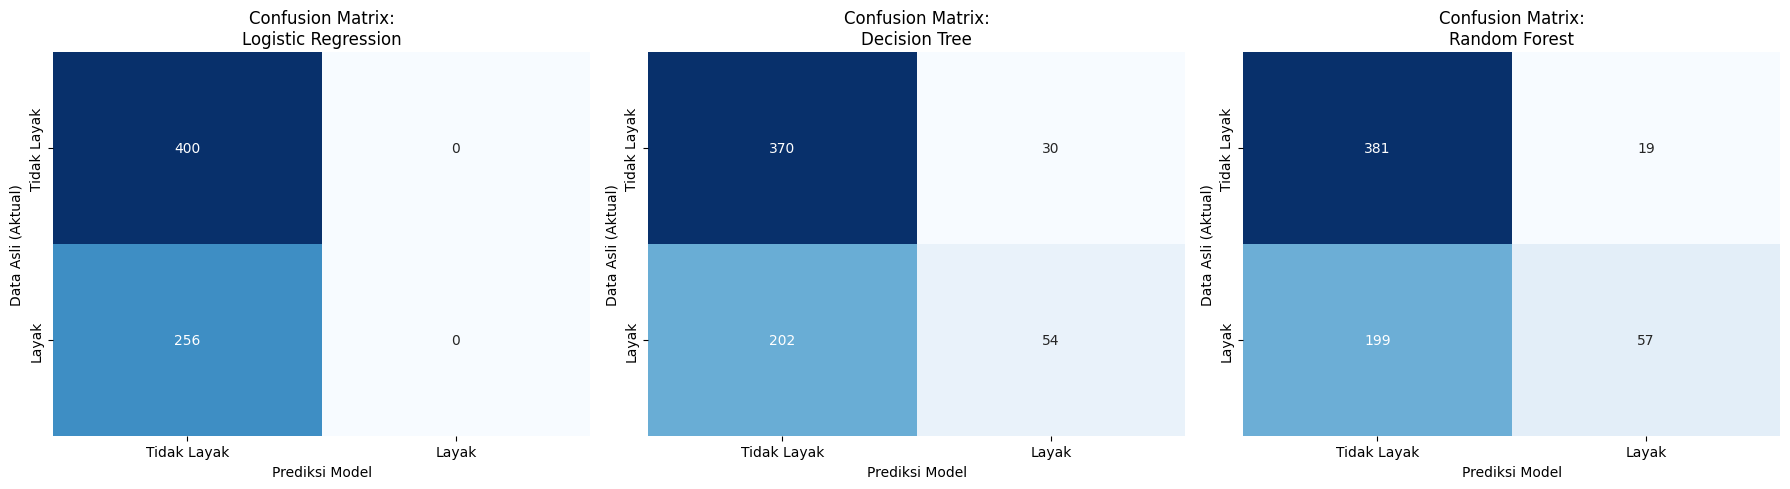

/tmp/ipykernel_10806/2054883135.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')


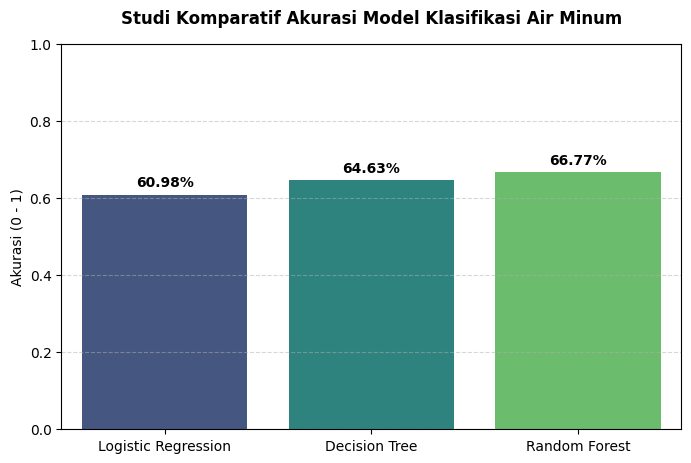

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {'Logistic Regression': model_lr, 'Decision Tree': model_dt, 'Random Forest': model_rf}
predictions = {}
accuracies = {}
# 1. Prediksi dan Cetak Laporan Detail
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    accuracies[name] = accuracy_score(y_test, y_pred)

    print(f"\n================ EVALUASI {name.upper()} ================")
    print(classification_report(y_test, y_pred))

# 2. Visualisasi Confusion Matrix untuk Ketiga Model (Sangat disukai Dosen)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Confusion Matrix:\n{name}')
    axes[i].set_xlabel('Prediksi Model')
    axes[i].set_ylabel('Data Asli (Aktual)')
    axes[i].set_xticklabels(['Tidak Layak', 'Layak'])
    axes[i].set_yticklabels(['Tidak Layak', 'Layak'])

plt.tight_layout()
plt.show()

# 3. Grafik Batang Perbandingan Akurasi
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')
plt.title('Studi Komparatif Akurasi Model Klasifikasi Air Minum', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Akurasi (0 - 1)')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.02, f'{height:.2%}', ha="center", fontweight='bold')

plt.show()